In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotters


# Galaxy Image Classification — Numerical Results

**Single source of truth** for all computed quantities cited in the report. Every number in the LaTeX `report/` text must trace to a cell in this notebook — sample sizes, model RMSEs, best epochs, parameter counts, per-label residuals, and the merger-fraction estimate with its bootstrap interval.

This notebook is *not itself* a Task deliverable. The 27 numbered tasks in `course_materials_sp2026/labs/lab_3/...pdf` are addressed in notebooks 01–06; this notebook simply re-loads the persisted artifacts (`artifacts/*.npz` and `artifacts/*.pt`) and renders the canonical tables and bar charts that the report cites. Re-running this notebook end-to-end should produce identical numbers from the unchanged artifacts, which makes report–notebook consistency an automatic check rather than a manual reconciliation.

In [2]:
# Load all results
split_data = np.load("artifacts/split_indices.npz")
resnet_data = np.load("artifacts/resnet_result.npz")
custom_data = np.load("artifacts/custom_result.npz", allow_pickle=True)
sched_data = np.load("artifacts/scheduler_result.npz")
aug_data = np.load("artifacts/augmented_result.npz")
eval_data = np.load("artifacts/evaluation_results.npz")
label_data = np.load("artifacts/galaxy_zoo_labels.npz")

# Optional artifacts (NB 04 ablation, NB 05b class-weighted loss)
ablation_path = Path("artifacts/custom_cnn_ablation.npz")
cw_path = Path("artifacts/class_weighted_result.npz")
ablation_data = np.load(ablation_path, allow_pickle=True) if ablation_path.exists() else None
cw_data = np.load(cw_path) if cw_path.exists() else None


## Dataset Summary

In [3]:
n_total = len(label_data["labels"])
n_train = len(split_data["train_idx"])
n_val = len(split_data["val_idx"])

dataset_summary = pd.DataFrame({
    "Quantity": ["Total galaxies", "Training set", "Validation set", "Number of labels"],
    "Value": [n_total, n_train, n_val, label_data["labels"].shape[1]],
})
dataset_summary

,Quantity,Value
0,Total galaxies,61578
1,Training set,49262
2,Validation set,12316
3,Number of labels,37


## Model Performance Summary

,Model,Best Val RMSE,Best Epoch,Parameters
0,Baseline (mean),0.163933,N/A,0
1,Custom CNN,0.095260,34,2786117
2,ResNet-18,0.095789,95,11195493
3,ResNet-18 + LR Scheduler,0.094346,40,2786117
4,ResNet-18 + Aug + LR Scheduler,0.091267,97,2786117
5,ResNet-18 + Aug + LR + Tree-weighted loss,0.114521,74,2786117


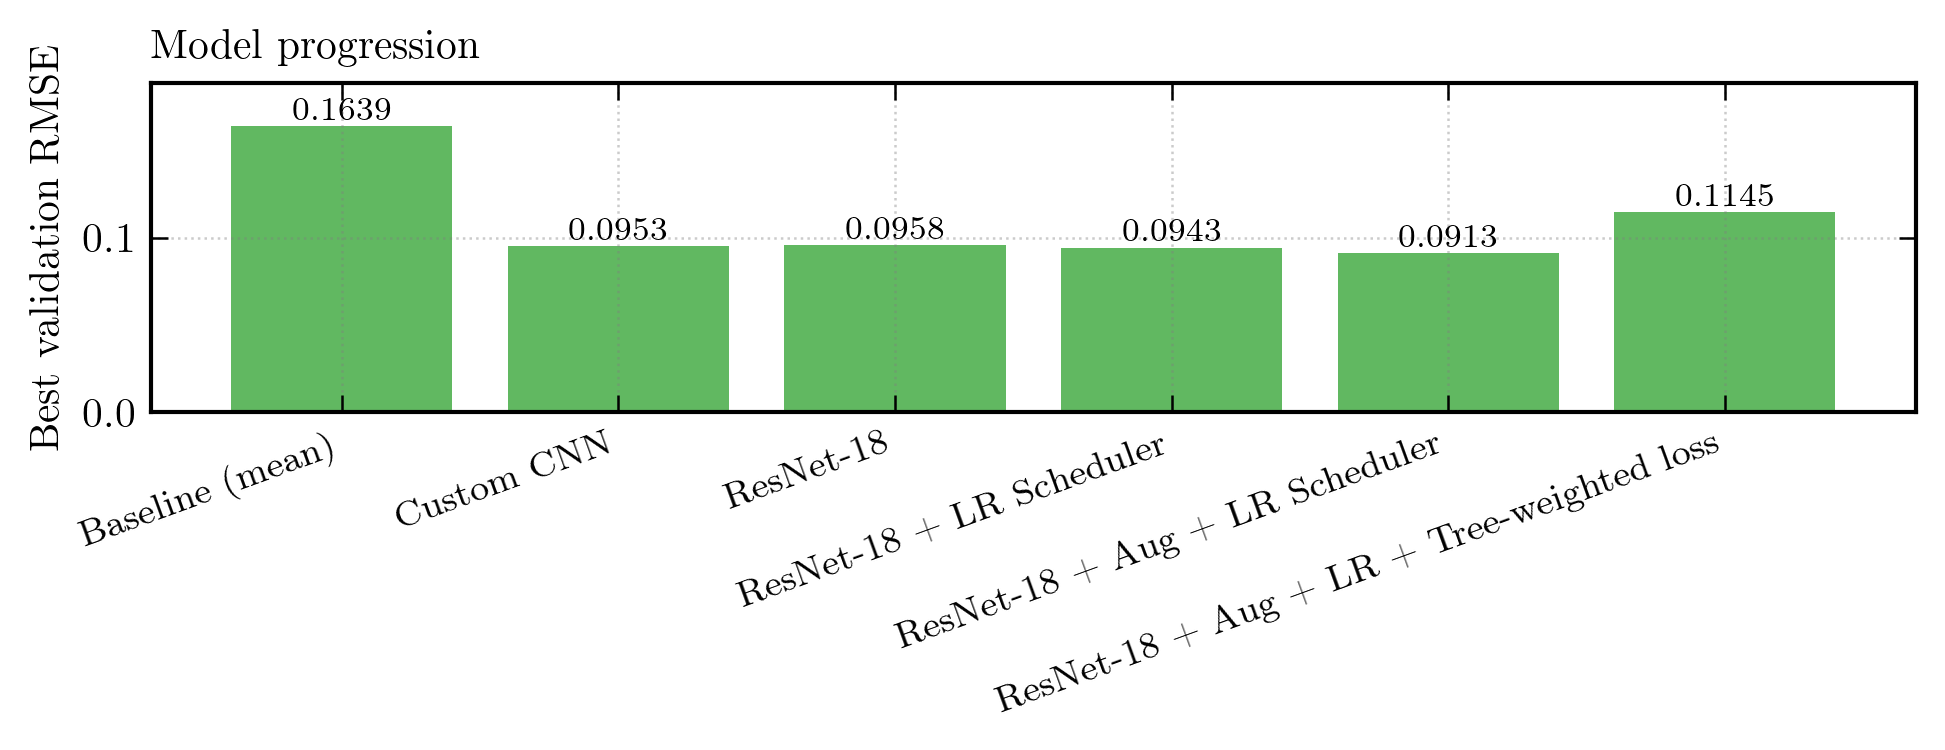

In [4]:
rows = [
    ("Baseline (mean)",                  float(split_data["baseline_val_rmse"]), "N/A", 0),
    ("Custom CNN",                       float(custom_data["best_val_loss"]),    int(custom_data["best_epoch"]) + 1, int(custom_data["n_parameters"])),
    ("ResNet-18",                        float(resnet_data["best_val_loss"]),    int(resnet_data["best_epoch"]) + 1, int(resnet_data["n_parameters"])),
    ("ResNet-18 + LR Scheduler",         float(sched_data["best_val_loss"]),     int(sched_data["best_epoch"]) + 1,  int(sched_data["n_parameters"])),
    ("ResNet-18 + Aug + LR Scheduler",   float(aug_data["best_val_loss"]),       int(aug_data["best_epoch"]) + 1,    int(aug_data["n_parameters"])),
]
if cw_data is not None:
    rows.append(("ResNet-18 + Aug + LR + Tree-weighted loss",
                 float(cw_data["best_val_loss"]),
                 int(cw_data["best_epoch"]) + 1,
                 int(cw_data["n_parameters"])))

performance = pd.DataFrame(rows, columns=["Model", "Best Val RMSE", "Best Epoch", "Parameters"])
display(performance)

# Bar chart of model progression (mean / Custom / ResNet / +Sched / +Aug / [+CW]).
ax = plotters.plot_model_progression_bar(
    [r[0] for r in rows], [r[1] for r in rows],
)
plt.show()


## Per-Label Performance (Best Model)

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Label,Bias,Scatter,RMSE
0,Spiral: Yes,-0.000749,0.167446,0.167448
1,No bar,0.038826,0.160455,0.165085
2,Spiral: No,0.035586,0.151920,0.156032
3,Edge-on: No,0.018754,0.153865,0.155003
4,Features/Disk,0.004601,0.150969,0.151039
5,Odd: Yes,0.019375,0.145589,0.146872
6,Odd: No,-0.018316,0.145633,0.146780
7,Smooth,-0.007559,0.144625,0.144822
8,Spiral: 2 arms,-0.000548,0.137735,0.137737
9,Obvious bulge,0.025937,0.124755,0.127423


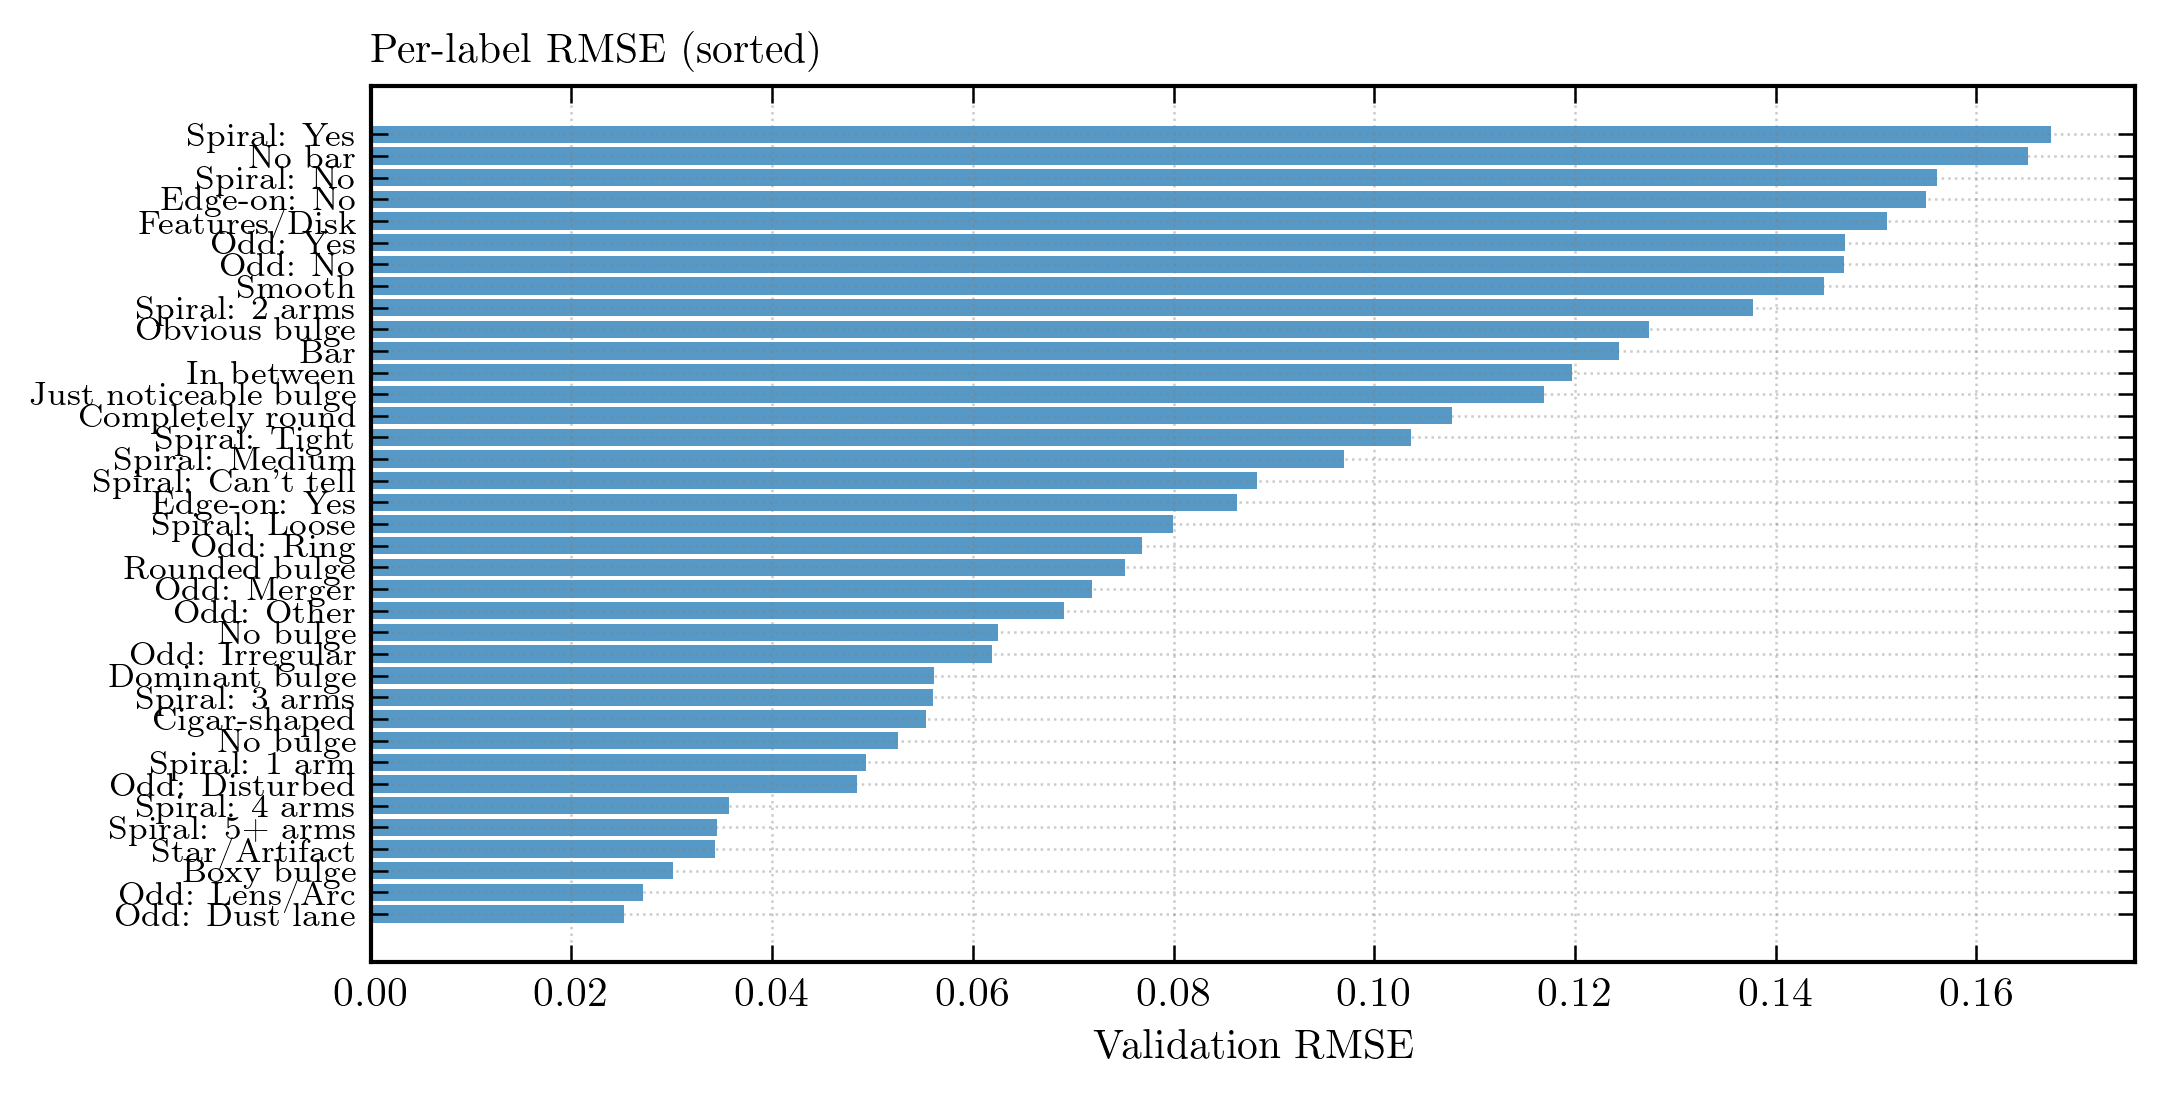

In [5]:
from ugdatalab.models.galaxy_zoo.constants import LABEL_COLUMNS, LABEL_DESCRIPTIVE

val_true = eval_data["val_true_labels"]
val_pred = eval_data["val_pred_labels"]

per_label_rmse = np.sqrt(((val_pred - val_true) ** 2).mean(axis=0))
per_label_bias = (val_pred - val_true).mean(axis=0)
per_label_scatter = (val_pred - val_true).std(axis=0)
label_desc_list = [LABEL_DESCRIPTIVE[c] for c in LABEL_COLUMNS]

per_label_df = pd.DataFrame({
    "Label": label_desc_list,
    "Bias": per_label_bias,
    "Scatter": per_label_scatter,
    "RMSE": per_label_rmse,
}).sort_values("RMSE", ascending=False).reset_index(drop=True)
display(per_label_df)

ax = plotters.plot_per_label_rmse_bar(label_desc_list, per_label_rmse)
plt.show()


## Merger Fraction

In [6]:
merger_fraction = float(eval_data["merger_fraction"])
test_pred = eval_data["test_pred_labels"]
n_test = len(eval_data["test_galaxy_ids"])
merger_idx = LABEL_COLUMNS.index("Class8.6")
merger_probs = test_pred[:, merger_idx]

# Bootstrap a crude 68% interval on the mean-probability estimator.
rng = np.random.default_rng(42)
boot = np.array([
    merger_probs[rng.integers(0, n_test, size=n_test)].mean()
    for _ in range(1000)
])
ci_lo, ci_hi = np.percentile(boot, [16, 84])

threshold_rows = []
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    n_above = int(np.sum(merger_probs > thresh))
    threshold_rows.append({"threshold": thresh, "n_above": n_above,
                           "fraction (%)": 100 * n_above / n_test})
threshold_table = pd.DataFrame(threshold_rows)

print(f"Test set size: {n_test}")
print(f"Mean-probability merger fraction: {merger_fraction*100:.2f}%  "
      f"(68% bootstrap interval: {ci_lo*100:.2f}–{ci_hi*100:.2f}%)")
print()
print("Comparison to Lotz et al. 2011:")
print("  Observed major merger rate at z≈0:   ~0.01–0.03 Gyr^-1")
print("  Merger observability timescale:      ~0.5–1 Gyr")
print("  Predicted local merger fraction:     ~0.5–3 %")
print()
print("Threshold sweep on our estimate:")
display(threshold_table)


Test set size: 79975
Mean-probability merger fraction: 4.01%  (68% bootstrap interval: 3.98–4.03%)

Comparison to Lotz et al. 2011:
  Observed major merger rate at z≈0:   ~0.01–0.03 Gyr^-1
  Merger observability timescale:      ~0.5–1 Gyr
  Predicted local merger fraction:     ~0.5–3 %

Threshold sweep on our estimate:


,threshold,n_above,fraction (%)
0,0.3,2417,3.022194
1,0.4,1143,1.429197
2,0.5,389,0.486402
3,0.6,74,0.092529
4,0.7,3,0.003751
